In [ ]:
import kagglehub
import os
# Download latest version
path1 = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print(os.listdir(path1)) 
BRAIN_IMAGES = os.path.join(path1, "Training")

Path to dataset files: C:\Users\sunda\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2
C:\Users\sunda\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2
['Testing', 'Training']


In [ ]:
# Download latest version
path2 = kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database")
print("Path to dataset files:", path2)
NEU_IMAGES = os.path.join(path2, "NEU-DET/train/images")

print(NEU_IMAGES)
print(os.listdir(NEU_IMAGES))

Path to dataset files: C:\Users\sunda\.cache\kagglehub\datasets\kaustubhdikshit\neu-surface-defect-database\versions\1
C:\Users\sunda\.cache\kagglehub\datasets\kaustubhdikshit\neu-surface-defect-database\versions\1\NEU-DET/train/images
['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [ ]:
# Download latest version
path3 = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path3)

CHEST_IMAGES = os.path.join(path3, "chest_xray/train")
print(os.listdir(CHEST_IMAGES))


Path to dataset files: C:\Users\sunda\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2
['NORMAL', 'PNEUMONIA']


In [ ]:
# Download latest version
path4 = kagglehub.dataset_download("apollo2506/eurosat-dataset")
print("Path to dataset files:", path4)

EUROSAT_IMAGES = os.path.join(path4, "EuroSAT")
print(os.listdir(EUROSAT_IMAGES))

Path to dataset files: C:\Users\sunda\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'label_map.json', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake', 'test.csv', 'train.csv', 'validation.csv']


In [54]:
import cv2
import numpy as np
import os
import pandas as pd
import tensorflow as tf
from skimage.feature import graycomatrix, graycoprops

# ======================================================
# SETTINGS
# ======================================================
OUTPUT_DIR = "glc"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE = 128
EPS = 1e-10
MAX_SAMPLES = 10000
SEED = 42

np.random.seed(SEED)

# DMVTD weights
A = 1 / 3
B = 1 / 3
C = 1 / 3

# GLCM params
DISTANCES = [1]
ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
LEVELS = 256
SYMMETRIC = True
NORMED = True

# ======================================================
# DATASETS
# ======================================================
DATASETS = [

    # ======================================
    # CUSTOM / TEXTURE / MEDICAL
    # ======================================
    {
        "name": "bone",
        "type": "folder",
        "path": "clahe_output"
    },
    {
        "name": "full_bone",
        "type": "folder",
        "path": "Dataset"
    },

    {
        "name": "neu_defect",
        "type": "folder",
        "path": NEU_IMAGES
    },

    {
        "name": "brain_mri",
        "type": "folder",
        "path": BRAIN_IMAGES
    },

    {
        "name": "chest_xray",
        "type": "folder",
        "path": CHEST_IMAGES
    },

    {
        "name": "eurosat",
        "type": "folder",
        "path": EUROSAT_IMAGES
    },
]

# ======================================================
# BALANCE DATASET
# ======================================================
def balance_dataset(images, labels, max_samples=1000):
    labels = np.array(labels)

    unique_classes = np.unique(labels)
    n_classes = len(unique_classes)

    samples_per_class = max_samples // n_classes

    balanced_images = []
    balanced_labels = []

    print("\nBalancing Dataset:")
    print(f"Classes: {unique_classes}")
    print(f"Samples/Class: {samples_per_class}")

    for cls in unique_classes:
        idx = np.where(labels == cls)[0]
        np.random.shuffle(idx)

        selected = idx[:samples_per_class]

        # keep original dtype
        selected_imgs = images[selected]

        balanced_images.extend(selected_imgs)
        balanced_labels.extend(
            [cls] * len(selected_imgs)
        )

        print(
            f"Class {cls} -> "
            f"{len(selected_imgs)}"
        )

    # convert WITHOUT object dtype
    balanced_images = np.array(
        balanced_images
    )

    balanced_labels = np.array(
        balanced_labels
    )

    # final shuffle
    shuffle_idx = np.random.permutation(
        len(balanced_labels)
    )

    return (
        balanced_images[shuffle_idx],
        balanced_labels[shuffle_idx]
    )

# ======================================================
# DMVTD
# ======================================================
from itertools import product

EPS = 1e-10

GRID = np.arange(0.0, 1.01, 0.1)


def compute_stats(values):

    values = np.asarray(values, dtype=np.float64)

    mean_v = np.mean(values)
    var_v = np.var(values)

    transition_v = (
        abs(values[0]-values[1]) +
        abs(values[1]-values[2]) +
        abs(values[2]-values[3]) +
        abs(values[3]-values[0])
    ) / 4

    mean_safe = mean_v + EPS
    var_safe = var_v + EPS
    transition_safe = transition_v + EPS

    # Power Fusion
    power = (
        (mean_safe ** A) *
        (var_safe ** B) *
        (transition_safe ** C)
    )

    # Additive Fusion
    additive = (
        A * mean_v +
        B * var_v +
        C * transition_v
    )

    return (
        mean_v,
        var_v,
        transition_v,
        power,
        additive
    )


# ======================================================
# FEATURE EXTRACTION
# ======================================================
def extract_features(img):
    img = cv2.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )

    if len(img.shape) == 3:
        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY
        )

    # CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    img = clahe.apply(img)

    # GLCM
    glcm = graycomatrix(
        img,
        distances=DISTANCES,
        angles=ANGLES,
        levels=LEVELS,
        symmetric=SYMMETRIC,
        normed=NORMED
    )

    contrast = graycoprops(
        glcm,
        "contrast"
    ).flatten()

    energy = graycoprops(
        glcm,
        "energy"
    ).flatten()

    homogeneity = graycoprops(
        glcm,
        "homogeneity"
    ).flatten()

    correlation = graycoprops(
        glcm,
        "correlation"
    ).flatten()

    # entropy
    entropy = []
    for ang in range(glcm.shape[3]):
        P = glcm[:, :, 0, ang]
        E = -np.sum(
            P * np.log2(P + EPS)
        )
        entropy.append(E)

    entropy = np.array(entropy)


    contrast_stats = compute_stats(contrast)
    energy_stats = compute_stats(energy)
    homogeneity_stats = compute_stats(homogeneity)
    correlation_stats = compute_stats(correlation)
    entropy_stats = compute_stats(entropy)

    power_features = np.hstack([

        contrast_stats[:4],
        energy_stats[:4],
        homogeneity_stats[:4],
        correlation_stats[:4],
        entropy_stats[:4]

    ])

    additive_features = np.hstack([

        (contrast_stats[0], contrast_stats[1], contrast_stats[2], contrast_stats[4]),
        (energy_stats[0], energy_stats[1], energy_stats[2], energy_stats[4]),
        (homogeneity_stats[0], homogeneity_stats[1], homogeneity_stats[2], homogeneity_stats[4]),
        (correlation_stats[0], correlation_stats[1], correlation_stats[2], correlation_stats[4]),
        (entropy_stats[0], entropy_stats[1], entropy_stats[2], entropy_stats[4])

    ])

    return power_features, additive_features



# ======================================================
# SAVE CSV
# ======================================================
def save_csv(
    power_list,
    additive_list,
    labels,
    dataset_name
):

    dataset_dir = os.path.join(
        OUTPUT_DIR,
        dataset_name
    )

    os.makedirs(dataset_dir, exist_ok=True)

    power_df = pd.DataFrame(power_list)
    additive_df = pd.DataFrame(additive_list)

    power_df["label"] = labels
    additive_df["label"] = labels

    power_df.to_csv(
        os.path.join(dataset_dir, "power.csv"),
        index=False
    )

    additive_df.to_csv(
        os.path.join(dataset_dir, "additive.csv"),
        index=False
    )

    print(f"Saved -> {dataset_dir}")


# ======================================================
# PROCESS
# ======================================================
def process_dataset(
    images,
    labels,
    dataset_name
):

    power_list = []
    additive_list = []
    label_list = []

    total = len(images)

    print(f"\nExtracting features for {dataset_name}")

    for i, (img, lbl) in enumerate(zip(images, labels)):

        img = np.asarray(img, dtype=np.uint8)

        power, additive = extract_features(img)

        power_list.append(power)
        additive_list.append(additive)
        label_list.append(lbl)

        if (i + 1) % 100 == 0:
            print(f"{i+1}/{total} done")

    save_csv(
        power_list,
        additive_list,
        label_list,
        dataset_name
    )


# ======================================================
# TF DATASET
# ======================================================
def process_tf_dataset(dataset):
    print(f"\nProcessing {dataset['name']}...")

    (x_train, y_train), \
    (x_test, y_test) = dataset["loader"]()

    X = np.concatenate(
        [x_train, x_test],
        axis=0
    )

    y = np.concatenate(
        [y_train, y_test],
        axis=0
    )

    X, y = balance_dataset(
        X,
        y,
        MAX_SAMPLES
    )

    process_dataset(
        X,
        y,
        dataset["name"]
    )


# ======================================================
# FOLDER DATASET
# ======================================================
def process_folder_dataset(dataset):
    path = dataset["path"]
    name = dataset["name"]

    print(f"\nProcessing {name}...")

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Dataset not found: {path}"
        )

    class_dirs = [
        d for d in sorted(os.listdir(path))
        if os.path.isdir(os.path.join(path, d))
    ]

    n_classes = len(class_dirs)
    samples_per_class = MAX_SAMPLES // n_classes

    print(
        f"Classes={n_classes}, "
        f"Samples/Class={samples_per_class}"
    )

    image_paths = []
    labels = []

    # ----------------------------
    # store file paths only
    # ----------------------------
    for class_name in class_dirs:
        class_path = os.path.join(path, class_name)

        class_files = []

        for img_name in os.listdir(class_path):
            if not img_name.lower().endswith(
                (".jpg", ".jpeg", ".png",
                 ".bmp", ".tif", ".tiff")
            ):
                continue

            img_path = os.path.join(
                class_path,
                img_name
            )
            class_files.append(img_path)

        np.random.shuffle(class_files)

        selected = class_files[:samples_per_class]

        image_paths.extend(selected)
        labels.extend(
            [class_name] * len(selected)
        )

        print(
            f"{class_name} -> "
            f"{len(selected)}"
        )

    # final shuffle
    idx = np.random.permutation(len(labels))
    image_paths = np.array(image_paths)[idx]
    labels = np.array(labels)[idx]

    # lazy load only selected images
    images = []
    for p in image_paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            images.append(img)

    process_dataset(
        images,
        labels,
        name
    )

# ======================================================
# RUNNER
# ======================================================
def run_all_datasets():
    for dataset in DATASETS:
        dtype = dataset["type"]

        if dtype == "tf":
            process_tf_dataset(
                dataset
            )

        elif dtype == "folder":
            process_folder_dataset(
                dataset
            )

        else:
            print(
                f"Skipping "
                f"{dataset['name']}"
            )

    print("\n" + "=" * 60)
    print("ALL DATASETS COMPLETE")
    print("=" * 60)

    print("\nGenerated CSVs:\n")

    for dataset in DATASETS:
        name = dataset["name"]
        print(f"glcm/{name}/power.csv")
        print(f"glcm/{name}/additive.csv")
        print()


# ======================================================
# MAIN
# ======================================================
if __name__ == "__main__":
    run_all_datasets()


Processing eurosat...
Classes=10, Samples/Class=1000
AnnualCrop -> 1000
Forest -> 1000
HerbaceousVegetation -> 1000
Highway -> 1000
Industrial -> 1000
Pasture -> 1000
PermanentCrop -> 1000
Residential -> 1000
River -> 1000
SeaLake -> 1000

Extracting features for eurosat
100/10000 done
200/10000 done
300/10000 done
400/10000 done
500/10000 done
600/10000 done
700/10000 done
800/10000 done
900/10000 done
1000/10000 done
1100/10000 done
1200/10000 done
1300/10000 done
1400/10000 done
1500/10000 done
1600/10000 done
1700/10000 done
1800/10000 done
1900/10000 done
2000/10000 done
2100/10000 done
2200/10000 done
2300/10000 done
2400/10000 done
2500/10000 done
2600/10000 done
2700/10000 done
2800/10000 done
2900/10000 done
3000/10000 done
3100/10000 done
3200/10000 done
3300/10000 done
3400/10000 done
3500/10000 done
3600/10000 done
3700/10000 done
3800/10000 done
3900/10000 done
4000/10000 done
4100/10000 done
4200/10000 done
4300/10000 done
4400/10000 done
4500/10000 done
4600/10000 done



Detected Datasets:
bone
brain_mri
chest_xray
eurosat
full_bone
neu_defect

################################################################################
RUNNING: BONE
################################################################################

bone_additive

Missing values per column:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
dtype: int64

--- SVM ---
Accuracy : 0.7884
Precision: 0.7978
Recall   : 0.7884
F1 Score : 0.7884

Confusion Matrix:
[[252  92]
 [ 43 251]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.73      0.79       344
           1       0.73      0.85      0.79       294

    accuracy                           0.79       638
   macro avg       0.79      0.79      0.79       638
weighted avg       0.80      0.79      0.79       638


--- KNN ---
Accuracy : 0.7665
Precision: 0.7703
Recal

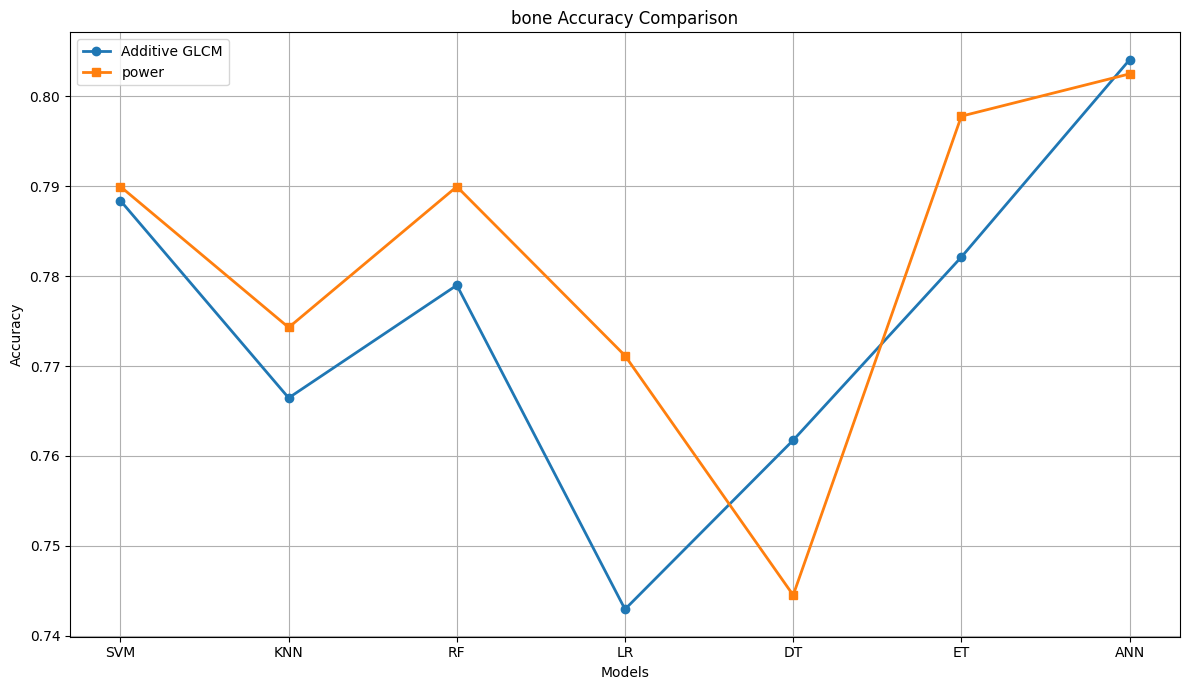


################################################################################
RUNNING: BRAIN_MRI
################################################################################

brain_mri_additive

Missing values per column:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
dtype: int64

--- SVM ---
Accuracy : 0.8500
Precision: 0.8544
Recall   : 0.8500
F1 Score : 0.8507

Confusion Matrix:
[[220  51   0   9]
 [ 13 231  13  23]
 [  4   9 254  13]
 [  8  17   8 247]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.79      0.84       280
           1       0.75      0.82      0.79       280
           2       0.92      0.91      0.92       280
           3       0.85      0.88      0.86       280

    accuracy                           0.85      1120
   macro avg       0.85      0.85      0.85      1120
weighted avg

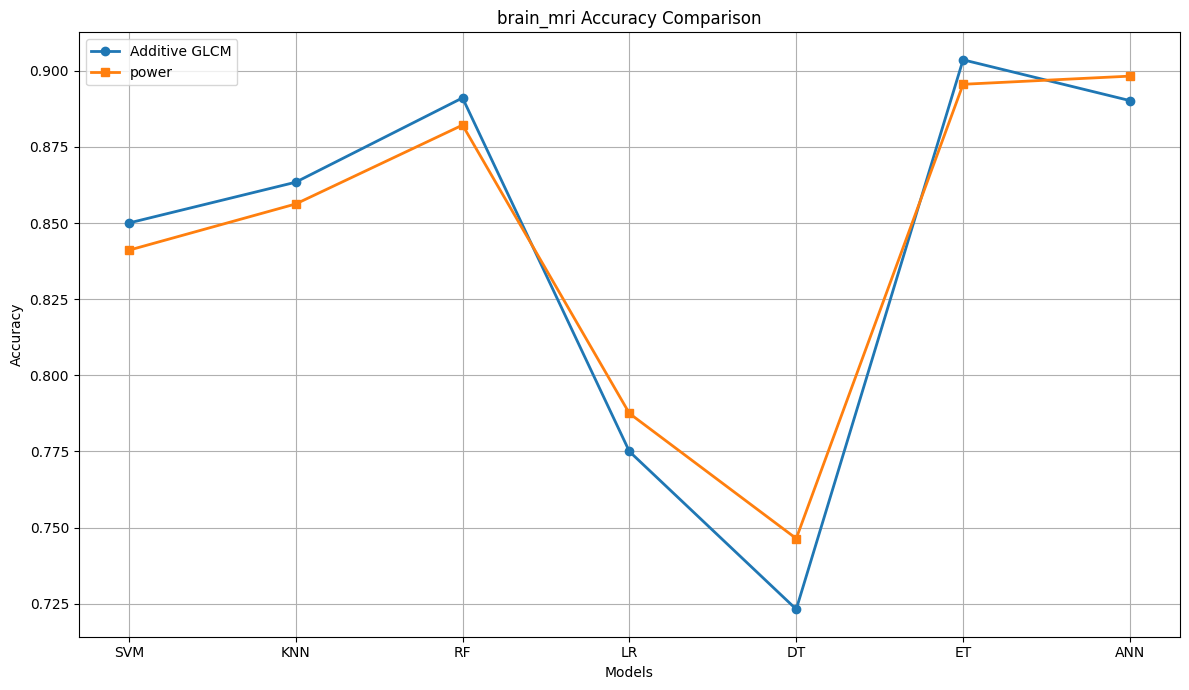


################################################################################
RUNNING: CHEST_XRAY
################################################################################

chest_xray_additive

Missing values per column:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
dtype: int64

--- SVM ---
Accuracy : 0.9349
Precision: 0.9354
Recall   : 0.9349
F1 Score : 0.9351

Confusion Matrix:
[[237  31]
 [ 37 739]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       268
           1       0.96      0.95      0.96       776

    accuracy                           0.93      1044
   macro avg       0.91      0.92      0.92      1044
weighted avg       0.94      0.93      0.94      1044


--- KNN ---
Accuracy : 0.9109
Precision: 0.9163
Recall   : 0.9109
F1 Score : 0.9125

Confusion Matrix:
[[238  30]
 [

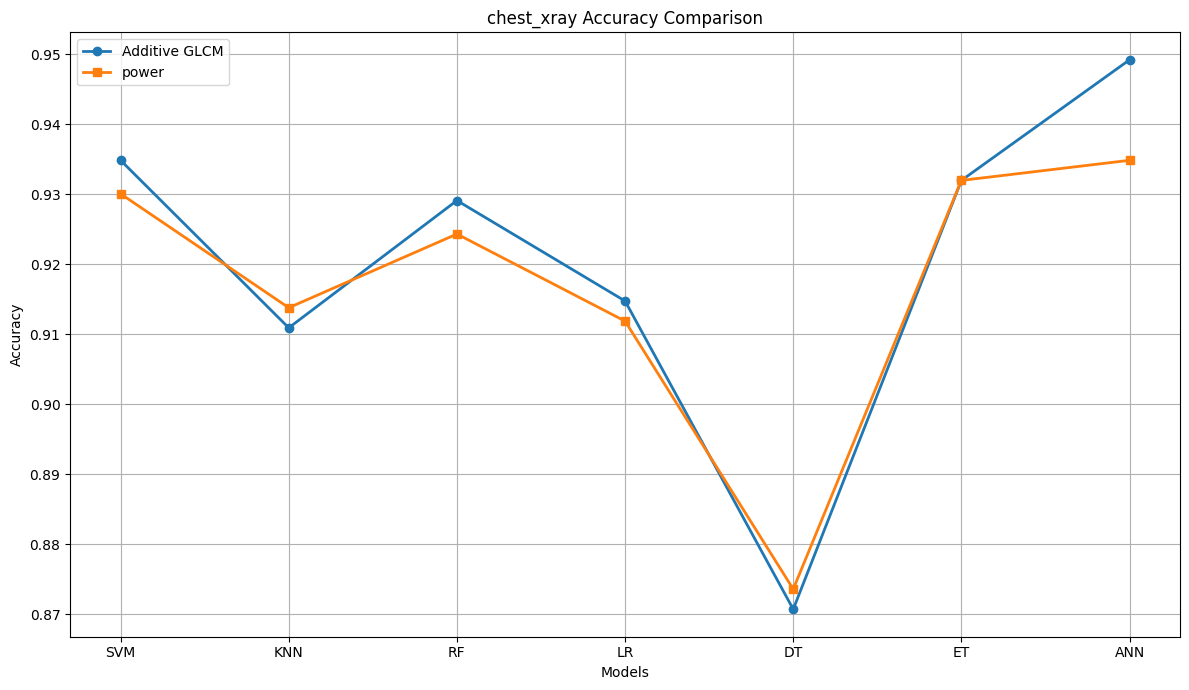


################################################################################
RUNNING: EUROSAT
################################################################################

eurosat_additive

Missing values per column:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
dtype: int64

--- SVM ---
Accuracy : 0.7390
Precision: 0.7342
Recall   : 0.7390
F1 Score : 0.7320

Confusion Matrix:
[[157   0   1  10   0  14   5   0   7   6]
 [  0 189   6   0   0   2   0   0   0   3]
 [  6   7 108   8  10  17  33  11   0   0]
 [ 14   2   7  74  26   5  40   3  29   0]
 [  1   0   0   4 174   0  14   7   0   0]
 [  8   8  11   1   0 161   5   0   6   0]
 [  7   1  22  17  17   3 128   2   3   0]
 [  0   1   1   0  13   0   4 181   0   0]
 [ 40   0   4  26   3  11   1   0 114   1]
 [  3   0   0   0   0   4   0   0   1 192]]

Classification Report:
              precision    recall  f1-scor

C:\Users\sunda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sunda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sunda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

Accuracy : 0.7600
Precision: 0.7556
Recall   : 0.7600
F1 Score : 0.7563

Confusion Matrix:
[[158   0   1  11   0  17   4   0   6   3]
 [  0 189   5   0   0   4   0   0   0   2]
 [  5   4 126  10   5  15  25   9   1   0]
 [ 10   2   8  98  21   4  21   4  32   0]
 [  0   0   1  10 172   0   8   8   1   0]
 [ 11   9   2   4   0 159   5   0  10   0]
 [  6   0  25  24  11   5 121   2   6   0]
 [  0   0   3   0   7   0   1 189   0   0]
 [ 28   0   2  27   3  17   8   0 114   1]
 [  2   0   0   0   0   3   0   0   1 194]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75       200
           1       0.93      0.94      0.94       200
           2       0.73      0.63      0.68       200
           3       0.53      0.49      0.51       200
           4       0.79      0.86      0.82       200
           5       0.71      0.80      0.75       200
           6       0.63      0.60      0.62       200
           7       0.

C:\Users\sunda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sunda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sunda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

Accuracy : 0.7445
Precision: 0.7394
Recall   : 0.7445
F1 Score : 0.7403

Confusion Matrix:
[[155   0   1  10   0  18   4   0  10   2]
 [  0 187   5   0   0   4   0   0   0   4]
 [  5   5 115  10   6  14  33   9   3   0]
 [ 11   2   6  91  21   7  24   3  35   0]
 [  0   0   0  10 172   0  10   7   1   0]
 [ 12  11   6   2   0 154   5   0  10   0]
 [  6   0  27  20  12   2 121   2  10   0]
 [  0   0   3   2   6   0   2 187   0   0]
 [ 35   1   2  25   3  12   7   0 114   1]
 [  1   1   0   0   0   4   0   0   1 193]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.78      0.73       200
           1       0.90      0.94      0.92       200
           2       0.70      0.57      0.63       200
           3       0.54      0.46      0.49       200
           4       0.78      0.86      0.82       200
           5       0.72      0.77      0.74       200
           6       0.59      0.60      0.60       200
           7       0.

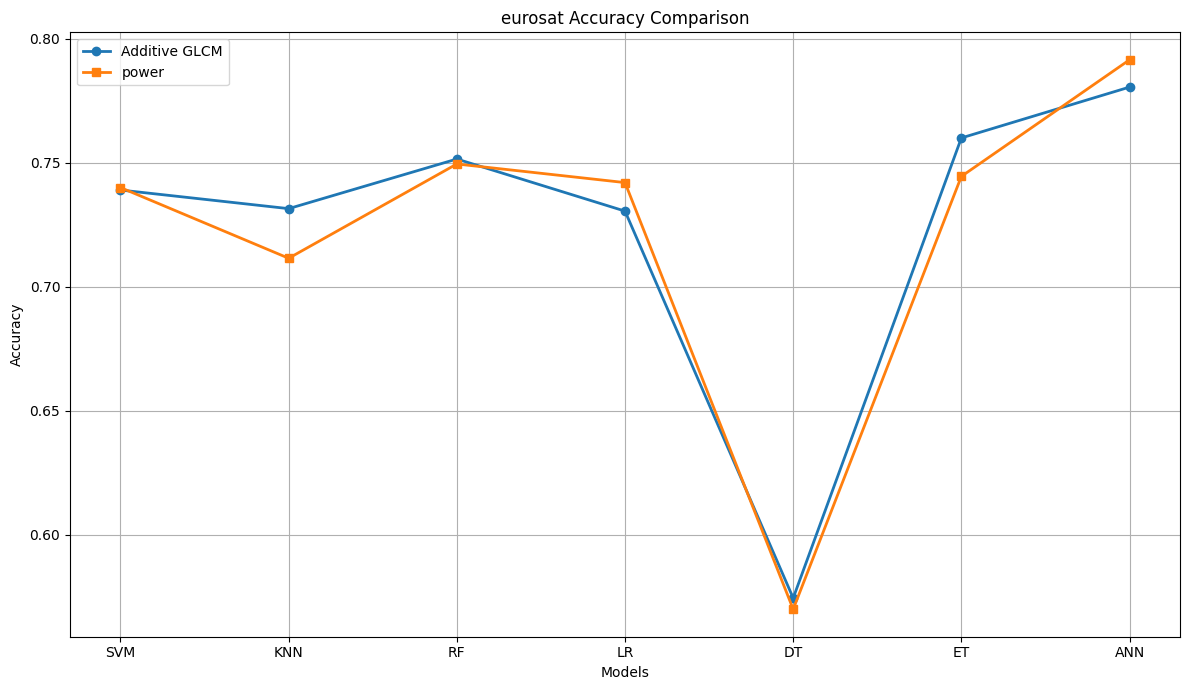


################################################################################
RUNNING: FULL_BONE
################################################################################

full_bone_additive

Missing values per column:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
dtype: int64

--- SVM ---
Accuracy : 0.7467
Precision: 0.7625
Recall   : 0.7467
F1 Score : 0.7434

Confusion Matrix:
[[24 14]
 [ 5 32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.63      0.72        38
           1       0.70      0.86      0.77        37

    accuracy                           0.75        75
   macro avg       0.76      0.75      0.74        75
weighted avg       0.76      0.75      0.74        75


--- KNN ---
Accuracy : 0.7067
Precision: 0.7095
Recall   : 0.7067
F1 Score : 0.7060

Confusion Matrix:
[[25 13]
 [ 9 28]]


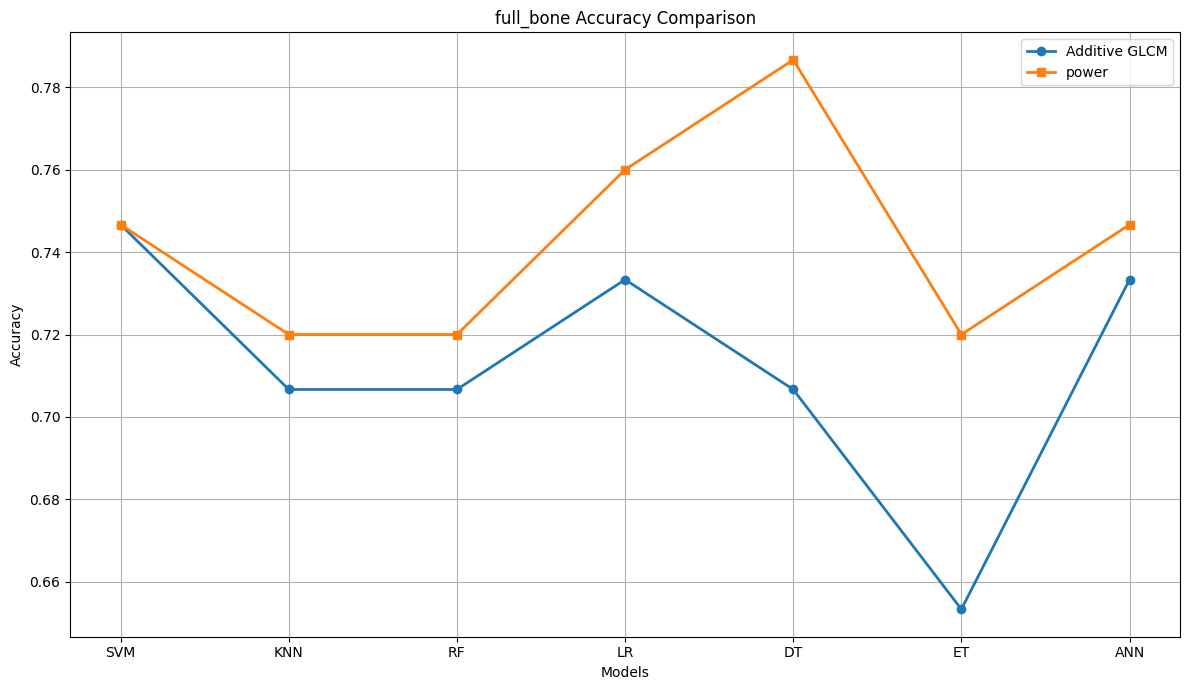


################################################################################
RUNNING: NEU_DEFECT
################################################################################

neu_defect_additive

Missing values per column:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
dtype: int64

--- SVM ---
Accuracy : 0.9410
Precision: 0.9436
Recall   : 0.9410
F1 Score : 0.9402

Confusion Matrix:
[[48  0  0  0  0  0]
 [ 0 47  0  0  0  1]
 [ 4  0 43  1  0  0]
 [ 0  0  0 46  1  1]
 [ 0  0  0  0 48  0]
 [ 0  3  0  6  0 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        48
           1       0.94      0.98      0.96        48
           2       1.00      0.90      0.95        48
           3       0.87      0.96      0.91        48
           4       0.98      1.00      0.99        48
           5   

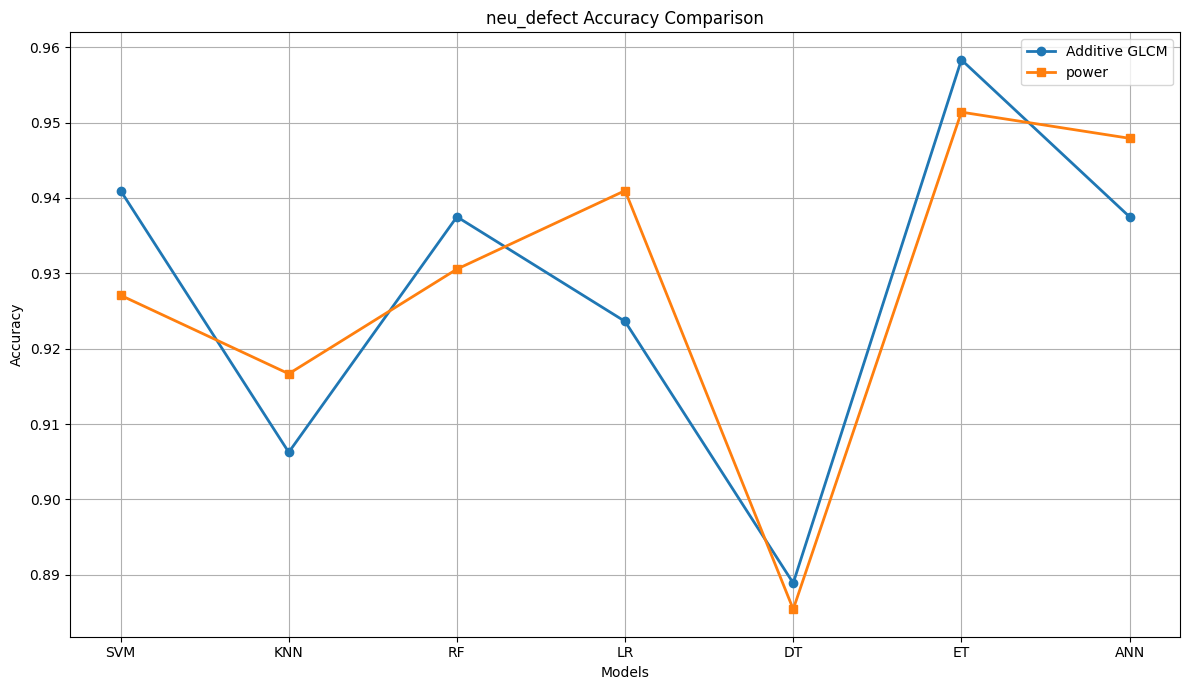

In [55]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


# =====================================================
# SETTINGS
# =====================================================
GLCM_DIR = "glc"
TEST_SIZE = 0.2
RANDOM_STATE = 42
EPOCHS = 100
BATCH_SIZE = 32

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


# =====================================================
# ANN MODEL
# =====================================================
class ANN(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)


# =====================================================
# TRAIN ANN
# =====================================================
def train_ann(X_train, X_test, y_train):
    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.long
    )

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    input_size = X_train.shape[1]
    num_classes = len(np.unique(y_train))

    model = ANN(
        input_size,
        num_classes
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(
            f"Epoch [{epoch + 1}/{EPOCHS}] "
            f"Loss={total_loss:.4f}"
        )

    model.eval()

    with torch.no_grad():
        X_test_tensor = X_test_tensor.to(device)
        outputs = model(X_test_tensor)

        _, predicted = torch.max(outputs, 1)
        y_pred = predicted.cpu().numpy()

    return y_pred


# =====================================================
# SHOW CONFUSION MATRIX
# =====================================================
def plot_confusion_matrix(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot()
    plt.title(title)
    plt.tight_layout()
    plt.show()


# =====================================================
# DATA PREPROCESSING
# =====================================================
def preprocess_features(df):
    X = df.drop(columns=["label"])

    # Convert everything to numeric
    X = X.apply(pd.to_numeric, errors="coerce")

    # Replace inf with NaN
    X = X.replace([np.inf, -np.inf], np.nan)

    print("\nMissing values per column:")
    print(X.isna().sum())

    # Fill NaN using mean
    imputer = SimpleImputer(strategy="mean")
    X = imputer.fit_transform(X)

    # Standardize
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    return X


# =====================================================
# RUN ONE CSV
# =====================================================
def run_experiment(file_path, dataset_name):
    print("\n" + "=" * 70)
    print(dataset_name)
    print("=" * 70)

    df = pd.read_csv(file_path)

    # -----------------------------
    # Label processing
    # -----------------------------
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(
        df["label"]
    )

    # -----------------------------
    # Feature processing
    # -----------------------------
    X = preprocess_features(df)

    # -----------------------------
    # Train / Test split
    # -----------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y
    )

    # -----------------------------
    # Models
    # -----------------------------
    models = {
        "SVM": SVC(
            kernel="rbf",
            C=1,
            gamma="scale"
        ),

        "KNN": KNeighborsClassifier(
            n_neighbors=5
        ),

        "RF": RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

        "LR": LogisticRegression(
            max_iter=500,
            random_state=RANDOM_STATE
        ),

        "DT": DecisionTreeClassifier(
            max_depth=5,
            random_state=RANDOM_STATE
        ),

        "ET": ExtraTreesClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    }

    model_names = []
    accuracies = []

    # =================================================
    # SKLEARN MODELS
    # =================================================
    for name, model in models.items():
        print(f"\n--- {name} ---")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)

        precision = precision_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1 Score : {f1:.4f}")

        print("\nConfusion Matrix:")
        print(confusion_matrix(y_test, y_pred))

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

        model_names.append(name)
        accuracies.append(acc)

    # =================================================
    # ANN
    # =================================================
    print("\n--- ANN ---")

    y_pred_ann = train_ann(
        X_train,
        X_test,
        y_train
    )

    acc = accuracy_score(
        y_test,
        y_pred_ann
    )

    precision = precision_score(
        y_test,
        y_pred_ann,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_ann,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_ann,
        average="weighted",
        zero_division=0
    )

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred_ann))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_ann))

    model_names.append("ANN")
    accuracies.append(acc)

    return model_names, accuracies


# =====================================================
# AUTO-DETECT DATASETS
# =====================================================
def get_datasets():
    datasets = {}

    for dataset_name in sorted(
        os.listdir(GLCM_DIR)
    ):
        dataset_path = os.path.join(
            GLCM_DIR,
            dataset_name
        )

        if not os.path.isdir(dataset_path):
            continue

        additive = os.path.join(
            dataset_path,
            "additive.csv"
        )

        power = os.path.join(
            dataset_path,
            "power.csv"
        )

        if (
            os.path.exists(additive)
            and
            os.path.exists(power)
        ):
            datasets[dataset_name] = {
                "additive": additive,
                "power": power,
            }

    return datasets


# =====================================================
# RUN ALL DATASETS
# =====================================================
def run_all():
    datasets = get_datasets()

    print("\nDetected Datasets:")
    for name in datasets:
        print(name)

    for dataset_name, files in datasets.items():
        print("\n" + "#" * 80)
        print(f"RUNNING: {dataset_name.upper()}")
        print("#" * 80)

        models, additive_acc = run_experiment(
            files["additive"],
            f"{dataset_name}_additive"
        )

        _, power_acc = run_experiment(
            files["power"],
            f"{dataset_name}_power"
        )
        # =============================================
        # FEATURE COMPARISON PLOT
        # =============================================
        plt.figure(figsize=(12, 7))

        plt.plot(
            models,
            additive_acc,
            marker="o",
            linewidth=2,
            label="Additive GLCM"
        )

        plt.plot(
            models,
            power_acc,
            marker="s",
            linewidth=2,
            label="power"
        )


        # for x, y in zip(models, hybrid_acc):
        #     plt.text(
        #         x,
        #         y + 0.003,
        #         f"{y:.3f}",
        #         ha="center"
        #     )

        plt.title(
            f"{dataset_name} Accuracy Comparison"
        )

        plt.xlabel("Models")
        plt.ylabel("Accuracy")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


# =====================================================
# MAIN
# =====================================================
if __name__ == "__main__":
    run_all()